# Cell 1: Imports & Setup


In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for preprocessing, modeling, and tuning
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statsmodels for Time Series Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")

# Cell 2: Data Loading & Preprocessing
**Action: Handling date formats, sorting chronologically, and checking for missing values.**

In [ ]:
import kagglehub
import pandas as pd
import os

# 1. Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")
print("Path to dataset files:", path)

# 2. Dynamically construct the file path
csv_file_path = os.path.join(path, 'tesla_deliveries_dataset_2015_2025.csv')

# 3. Load the dataset
df = pd.read_csv(csv_file_path)

# 4. Create Date column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

# 5. Sort chronologically (Crucial for time series!)
df = df.sort_values('Date').reset_index(drop=True)

# 6. Dataset info
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 7. First rows
df.head()

Path to dataset files: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations 

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


# Cell 3: Exploratory Data Analysis (EDA)
**Action: Visualizing sales trends over time, price distributions, and feature correlations.**

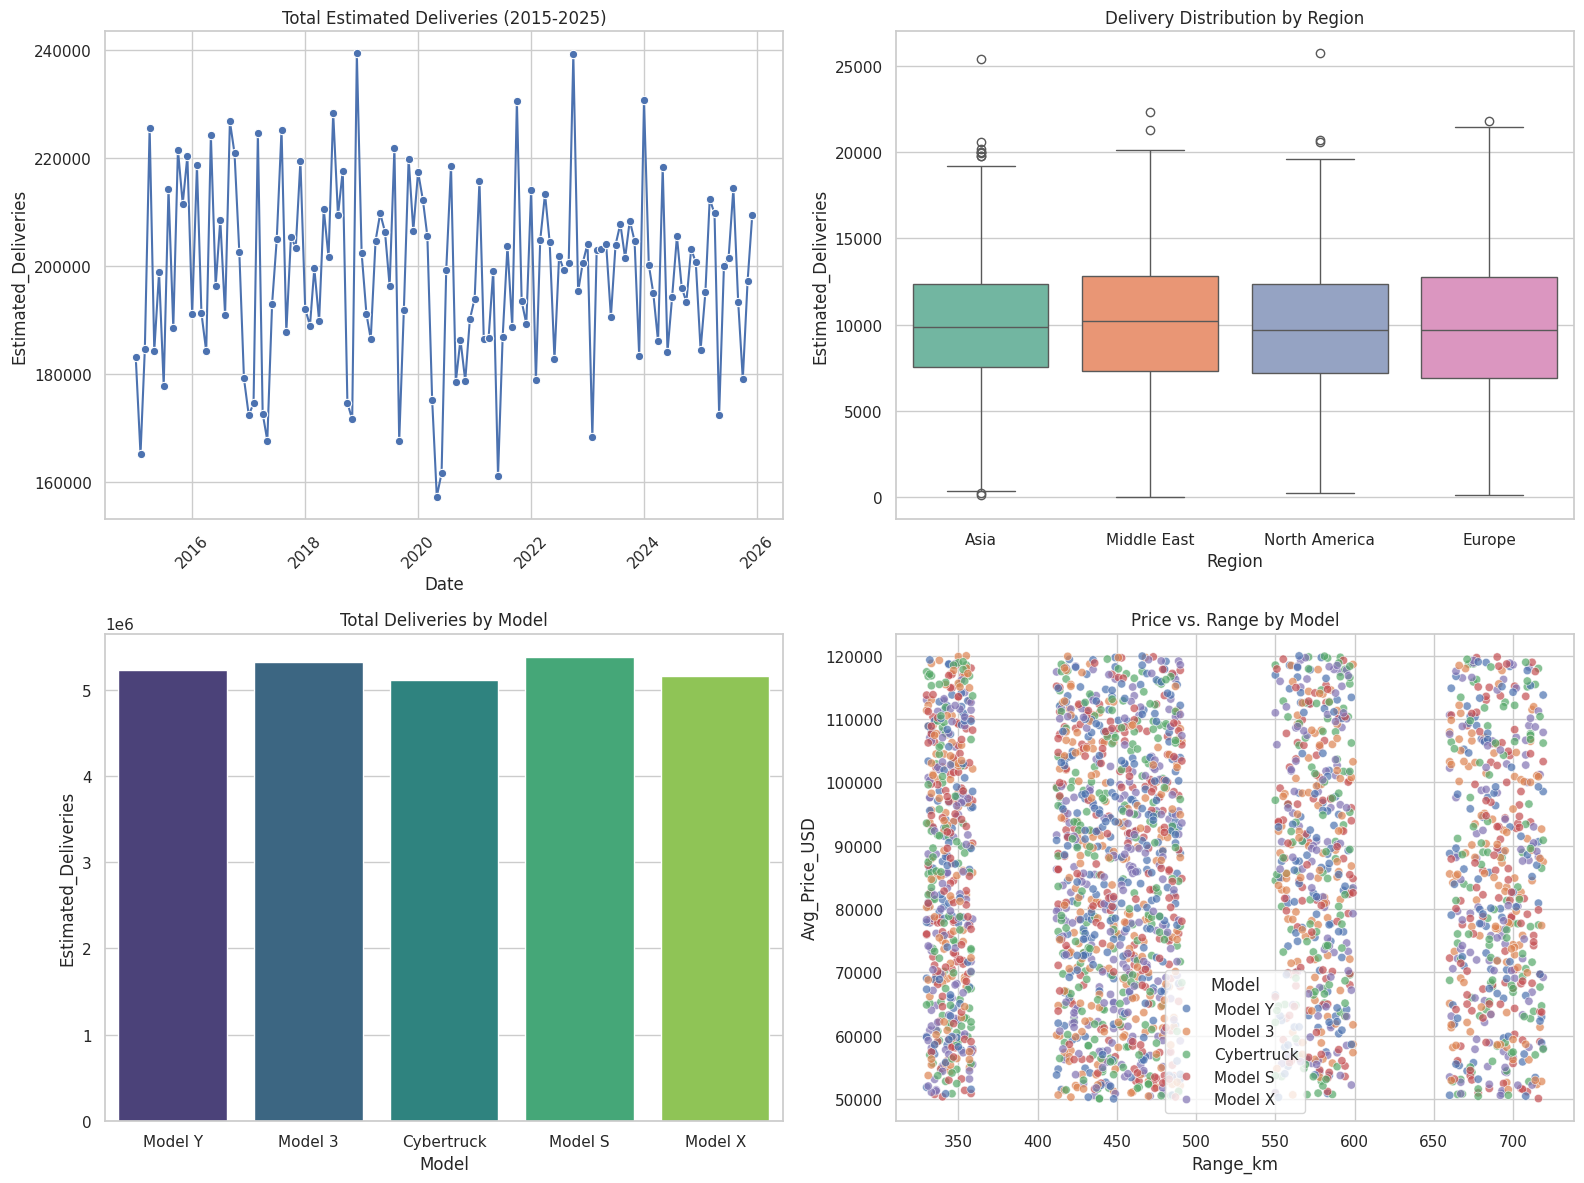

In [11]:
plt.figure(figsize=(16, 12))

# Plot 1: Total Estimated Deliveries Over Time
plt.subplot(2, 2, 1)
monthly_sales = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='Date', y='Estimated_Deliveries', marker='o')
plt.title('Total Estimated Deliveries (2015-2025)')
plt.xticks(rotation=45)

# Plot 2: Deliveries by Region
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Region', y='Estimated_Deliveries', palette='Set2')
plt.title('Delivery Distribution by Region')

# Plot 3: Deliveries by Vehicle Model
plt.subplot(2, 2, 3)
sns.barplot(data=df, x='Model', y='Estimated_Deliveries', estimator=sum, ci=None, palette='viridis')
plt.title('Total Deliveries by Model')

# Plot 4: Average Price vs Range 
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='Range_km', y='Avg_Price_USD', hue='Model', alpha=0.7)
plt.title('Price vs. Range by Model')

plt.tight_layout()
plt.show()

# Cell 4: Feature Engineering
**Action: Creating new temporal and derived features to improve regression model performance.**

In [12]:
# Extract temporal features
df['Quarter'] = df['Date'].dt.quarter
df['Is_Year_End'] = df['Month'].apply(lambda x: 1 if x == 12 else 0)

# Create derived ratios (Value proposition features)
df['Price_per_Range_km'] = df['Avg_Price_USD'] / df['Range_km']
df['Price_per_kWh'] = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']

# Define Target and Features for Regression
# (We exclude 'Production_Units' to avoid target leakage, assuming we want to predict sales without knowing exact production)
target = 'Estimated_Deliveries'
features = [
    'Region', 'Model', 'Avg_Price_USD', 'Battery_Capacity_kWh', 
    'Range_km', 'Source_Type', 'Charging_Stations', 
    'Quarter', 'Is_Year_End', 'Price_per_Range_km'
]

X = df[features]
y = df[target]

# Cell 5: Pipeline Construction & Hyperparameter Tuning
**Action: Building a robust ColumnTransformer, applying cross-validation, and tuning a RandomForestRegressor.**

In [13]:
# Split data sequentially to respect time dimensions (80% train, 20% test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Define Preprocessing Steps
numeric_features = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Price_per_Range_km']
numeric_transformer = StandardScaler()

categorical_features = ['Region', 'Model', 'Source_Type', 'Quarter', 'Is_Year_End']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full ML Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Define Hyperparameter Grid for Tuning
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

# Use TimeSeriesSplit for Cross Validation to prevent future data leakage
tscv = TimeSeriesSplit(n_splits=3)

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

# Train the model
print("Training and tuning model...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Training and tuning model...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Hyperparameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}


# Cell 6: Regression Model Evaluation
**Action: Testing the tuned model on unseen data.**

--- Regression Model Performance ---
Mean Absolute Error (MAE): 2960.95
Root Mean Squared Error (RMSE): 3682.23
R-Squared (R2): -0.0198


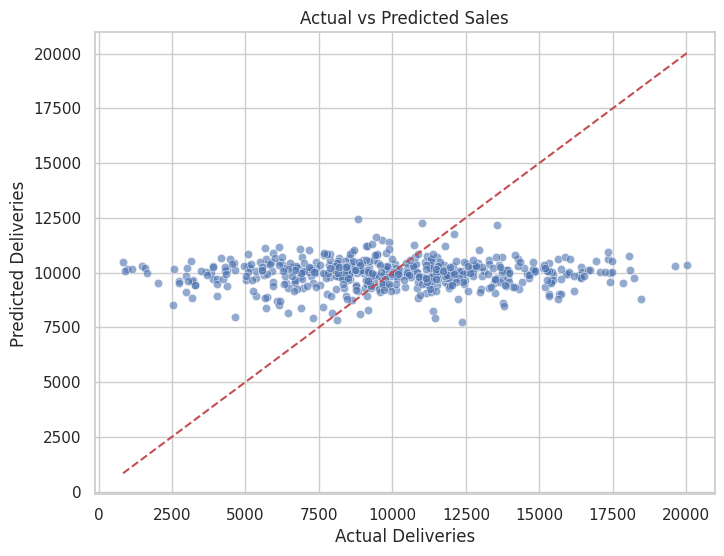

In [14]:
# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Regression Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R2): {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted Sales')
plt.show()

# Cell 7: Time Series Forecasting (SARIMA)
**Action: Aggregating data globally to forecast overall future deliveries using seasonal ARIMA.**

Training TS points: 105, Testing TS points: 27
Time Series Forecast RMSE: 20885.34


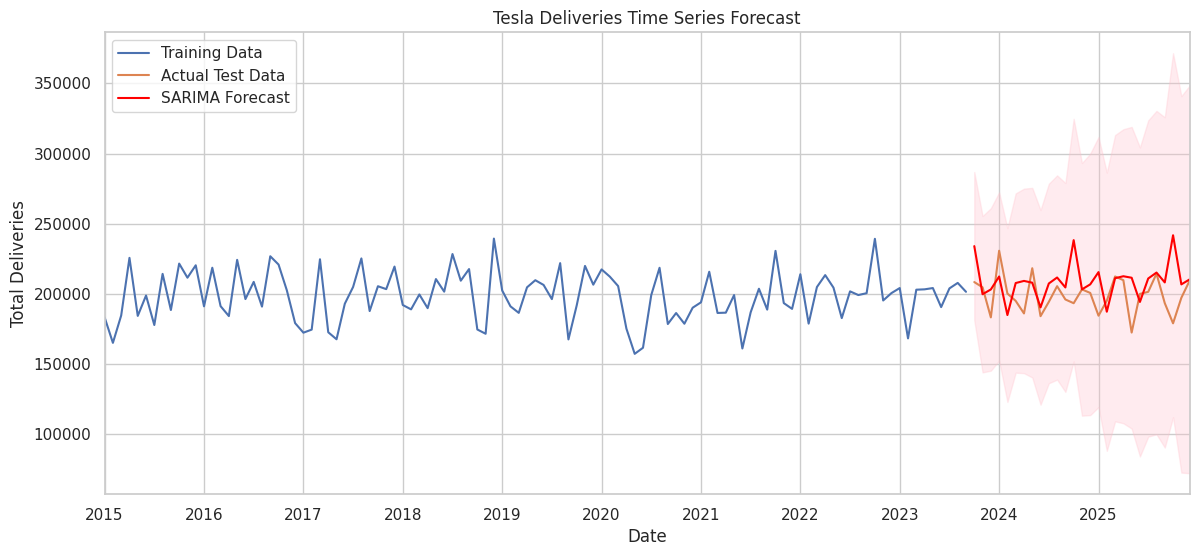

In [15]:
# Aggregate data monthly for pure time series forecasting
ts_data = df.groupby('Date')['Estimated_Deliveries'].sum()
ts_data.index = pd.DatetimeIndex(ts_data.index).to_period('M')

# Split Time Series (80% Train, 20% Test)
train_size = int(len(ts_data) * 0.8)
train_ts, test_ts = ts_data.iloc[:train_size], ts_data.iloc[train_size:]

print(f"Training TS points: {len(train_ts)}, Testing TS points: {len(test_ts)}")

# Define and fit SARIMA model
# (Order 1,1,1 and Seasonal 1,1,1,12 to account for yearly seasonality over 12 months)
sarima_model = SARIMAX(train_ts, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit(disp=False)

# Generate forecast for the test period
forecast = sarima_results.get_forecast(steps=len(test_ts))
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Calculate Time Series Metric
ts_rmse = np.sqrt(mean_squared_error(test_ts, forecast_mean))
print(f"Time Series Forecast RMSE: {ts_rmse:.2f}")

# Visualize the Forecast
plt.figure(figsize=(14, 6))
train_ts.plot(label='Training Data')
test_ts.plot(label='Actual Test Data')
forecast_mean.plot(label='SARIMA Forecast', color='red')
plt.fill_between(conf_int.index.to_timestamp(), 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Tesla Deliveries Time Series Forecast')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.show()